# 03 – Stage 1 Triad Analysis

Full empirical analysis across **3 triads × 3 markets = 9 markets**:

| Triad | Base | Similar | Dissimilar |
|-------|------|---------|------------|
| Politics | Trump 2024 election | Harris popular vote | Bitcoin $100k |
| Crypto | BTC $100k (Dec 23) | MicroStrategy BTC | Oscars Best Picture |
| Sports | Saquon Barkley SB MVP | SGA NBA Finals MVP | Nikki Haley Iowa |

**Within-triad analysis** (Sections 1-4) runs for each triad independently.  
**Cross-triad analysis** (Section 5) tests whether conclusions are consistent.

In [13]:
import sys, pathlib, logging, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))
logging.basicConfig(level=logging.WARNING)
warnings.filterwarnings("ignore", category=RuntimeWarning)

import numpy as np
import pandas as pd
import matplotlib
matplotlib.rcParams.update({"figure.dpi": 120, "savefig.dpi": 150})
import matplotlib.pyplot as plt

from src.config import TRIADS, ALL_MARKETS, DATA_PROCESSED
from src.analyze.return_distribution import (
    cross_triad_stats, cross_triad_tail_table,
    plot_return_histograms, plot_qq, plot_tail_ccdf,
)
from src.analyze.volatility import (
    plot_acf_panels, plot_acf_overlay,
    plot_rolling_vol_with_price, ljung_box_test, burst_summary, detect_bursts,
)
from src.analyze.reversal import (
    plot_conditional_returns, cross_triad_reversal_table,
)
from src.analyze.liquidity_regression import (
    plot_bin_stratification, plot_deadline_effect,
    ols_volatility_activity,
)
from src.analyze.cross_triad import (
    within_triad_summary, cross_triad_consistency,
    stage2_decision_table, plot_signature_comparison, plot_kurtosis_comparison,
)

## Load feature DataFrames

In [14]:
# Per-market feature DataFrames
all_features: dict[str, pd.DataFrame] = {}
for m in ALL_MARKETS:
    p = DATA_PROCESSED / f"features_{m['slug']}.parquet"
    if p.exists():
        all_features[m['slug']] = pd.read_parquet(p)

# Group by triad
triad_features: dict[str, dict[str, pd.DataFrame]] = {}
for tid, markets in TRIADS.items():
    triad_features[tid] = {
        m['slug']: all_features[m['slug']]
        for m in markets if m['slug'] in all_features
    }

# Summary
for tid, fds in triad_features.items():
    total = sum(len(df) for df in fds.values())
    print(f"Triad '{tid}': {len(fds)} markets, {total:,} total rows")

Triad 'politics': 3 markets, 21,158 total rows
Triad 'crypto': 3 markets, 1,302 total rows
Triad 'sports': 3 markets, 2,018 total rows


---
# Section 1 – Return-Distribution Signatures

For each triad: histograms, QQ plots, tail CCDF, summary statistics, power-law fits.


════════════════════════════════════════════════════════════
  TRIAD: politics
════════════════════════════════════════════════════════════


,n,mean,std,skewness,kurtosis,min,max,jarque_bera_stat,jarque_bera_p,role
market_slug,,,,,,,,,,
will-donald-trump-win-the-2024-us-presidential-election,7332,0.0001,0.0151,1.1413,121.3462,-0.3228,0.3263,4.500046e+06,0.0,base
will-kamala-harris-win-the-popular-vote-in-the-2024-presidential-election,7211,0.0001,0.0668,-5.0025,1459.5518,-3.1781,3.0466,6.400939e+08,0.0,similar
will-bitcoin-hit-100k-in-2024,6612,0.0012,0.0923,40.0928,2570.1424,-0.7485,5.9223,1.821623e+09,0.0,dissimilar


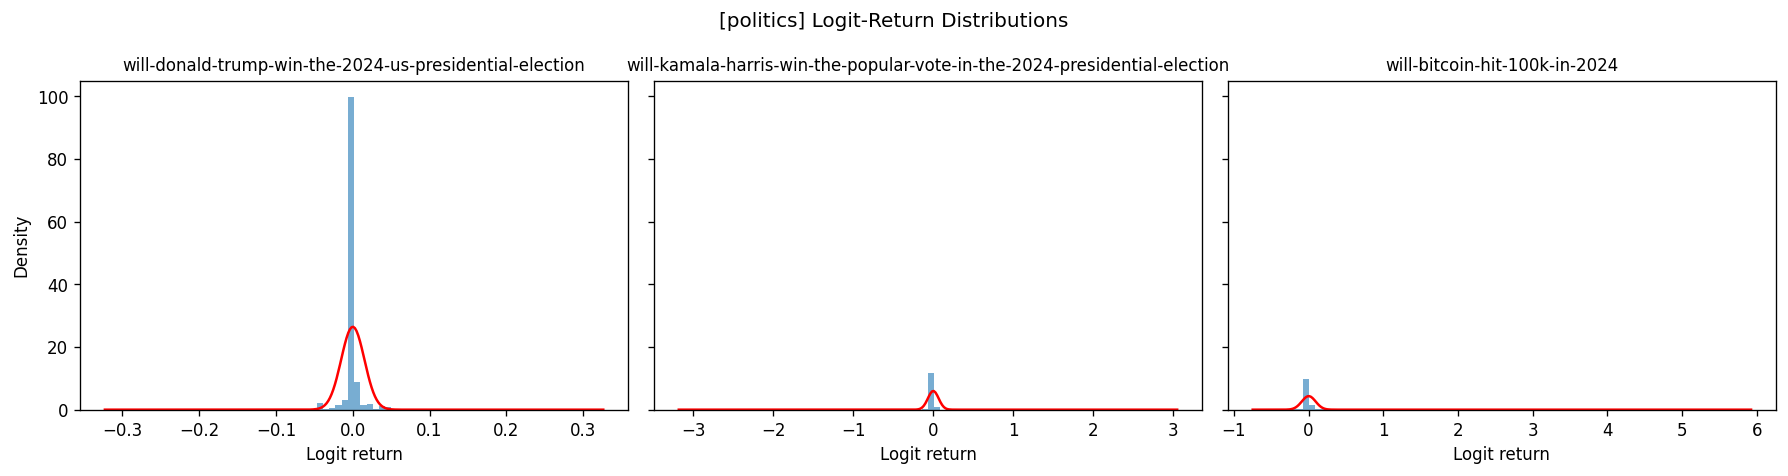

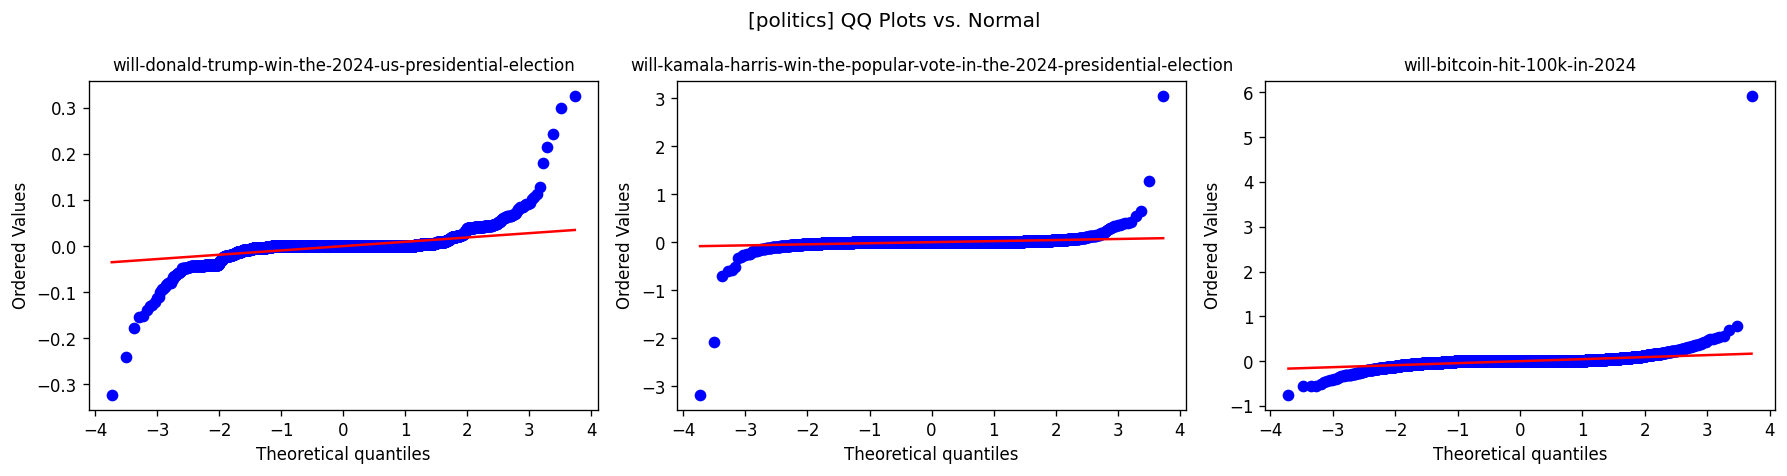


════════════════════════════════════════════════════════════
  TRIAD: crypto
════════════════════════════════════════════════════════════


,n,mean,std,skewness,kurtosis,min,max,jarque_bera_stat,jarque_bera_p,role
market_slug,,,,,,,,,,
will-bitcoin-hit-100k-again-in-2024-dec-23,183,-0.0179,0.2795,-0.4787,10.9898,-1.7278,1.4533,927.8968,0.0,base
will-microstrategy-purchase-more-bitcoin-in-2024-dec-16,166,0.0277,0.4913,6.3467,54.1911,-1.3740,4.5240,21426.4374,0.0,similar
oscars-best-picture-will-anora-win-best-picture-at-the-2025-oscars,950,0.0007,0.0740,4.1140,104.6047,-0.7200,1.2011,435806.0187,0.0,dissimilar


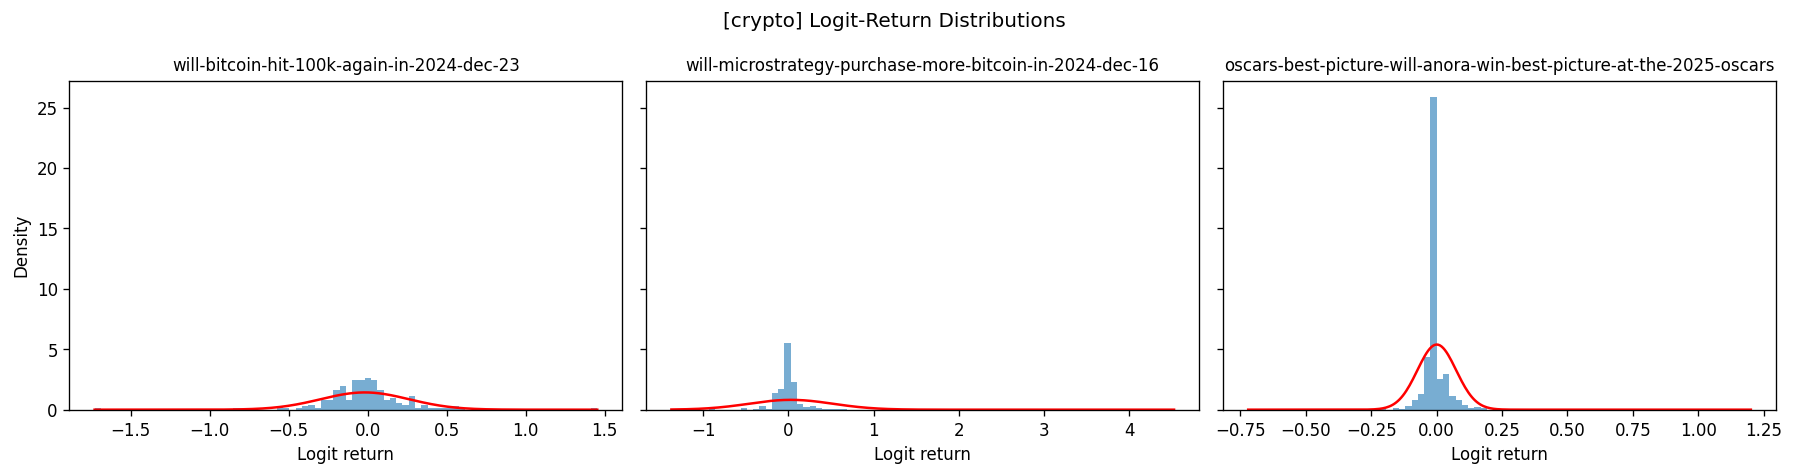

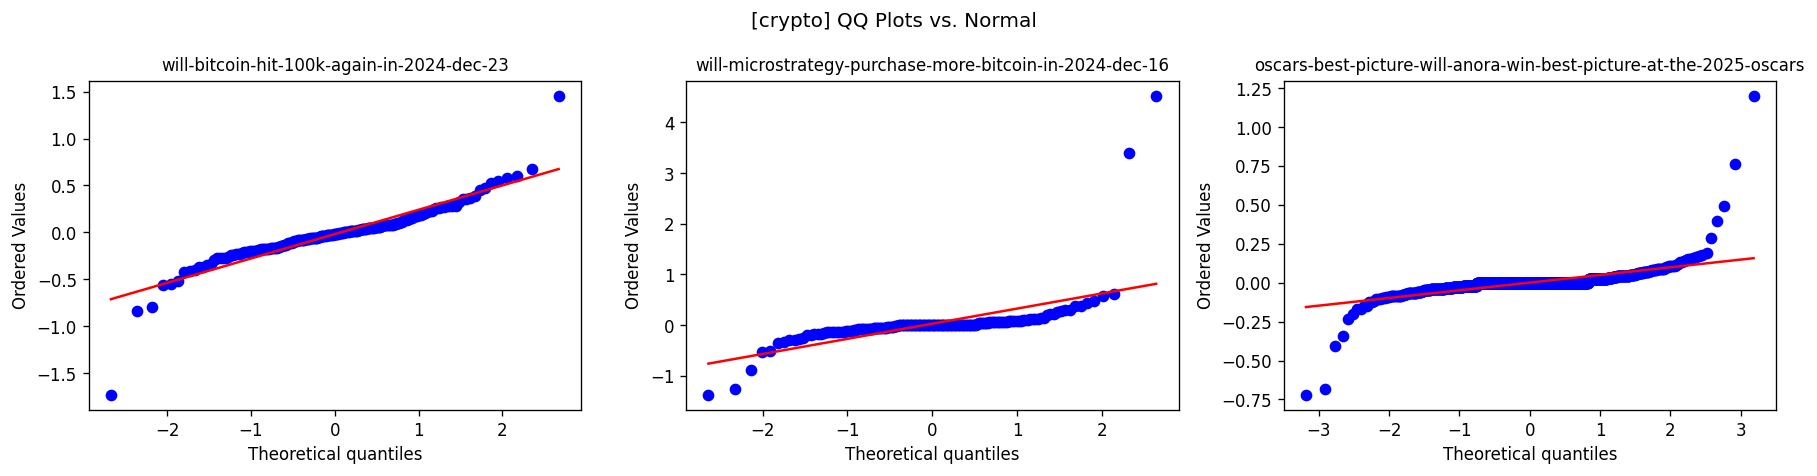


════════════════════════════════════════════════════════════
  TRIAD: sports
════════════════════════════════════════════════════════════


,n,mean,std,skewness,kurtosis,min,max,jarque_bera_stat,jarque_bera_p,role
market_slug,,,,,,,,,,
will-saquon-barkley-win-super-bowl-lix-mvp,375,-0.0004,0.0529,-3.0586,69.6449,-0.5469,0.4909,7.637235e+04,0.0,base
will-shai-gilgeous-alexander-win-the-2025-nba-finals-mvp,1496,0.0042,0.1507,7.1519,152.1896,-1.0747,3.1568,1.456497e+06,0.0,similar
will-nikki-haley-win-the-2024-republican-iowa-caucus,144,-0.0325,0.5217,-1.2324,43.8348,-3.4761,3.7945,1.156539e+04,0.0,dissimilar


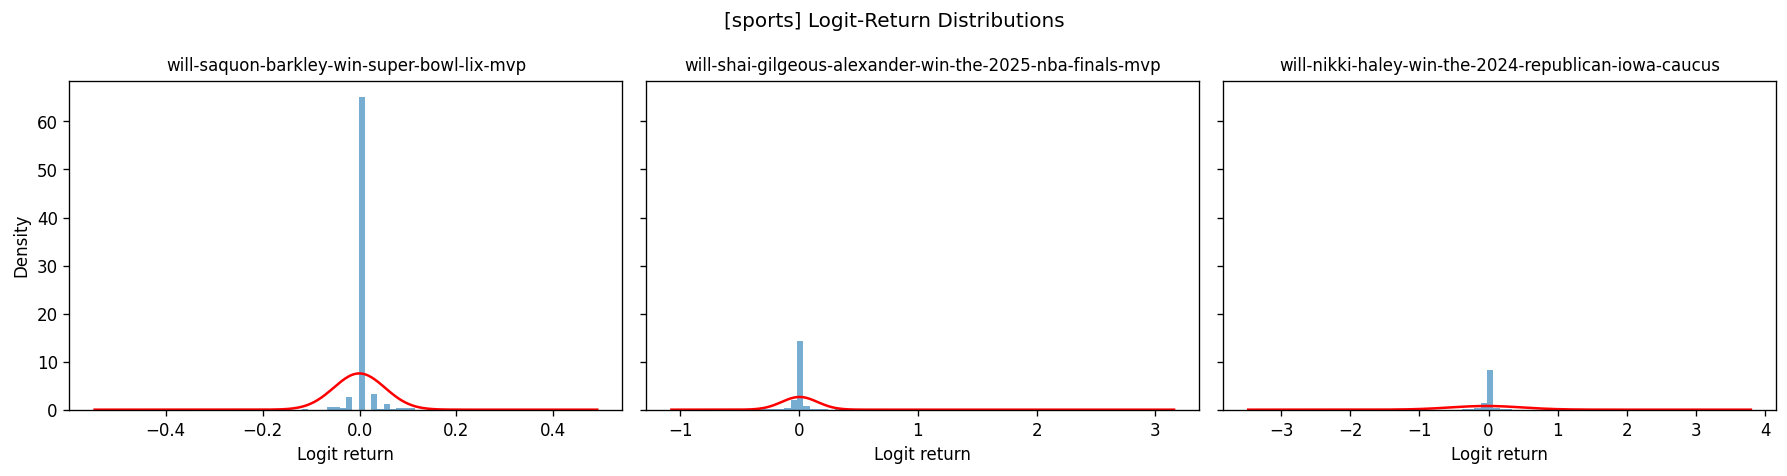

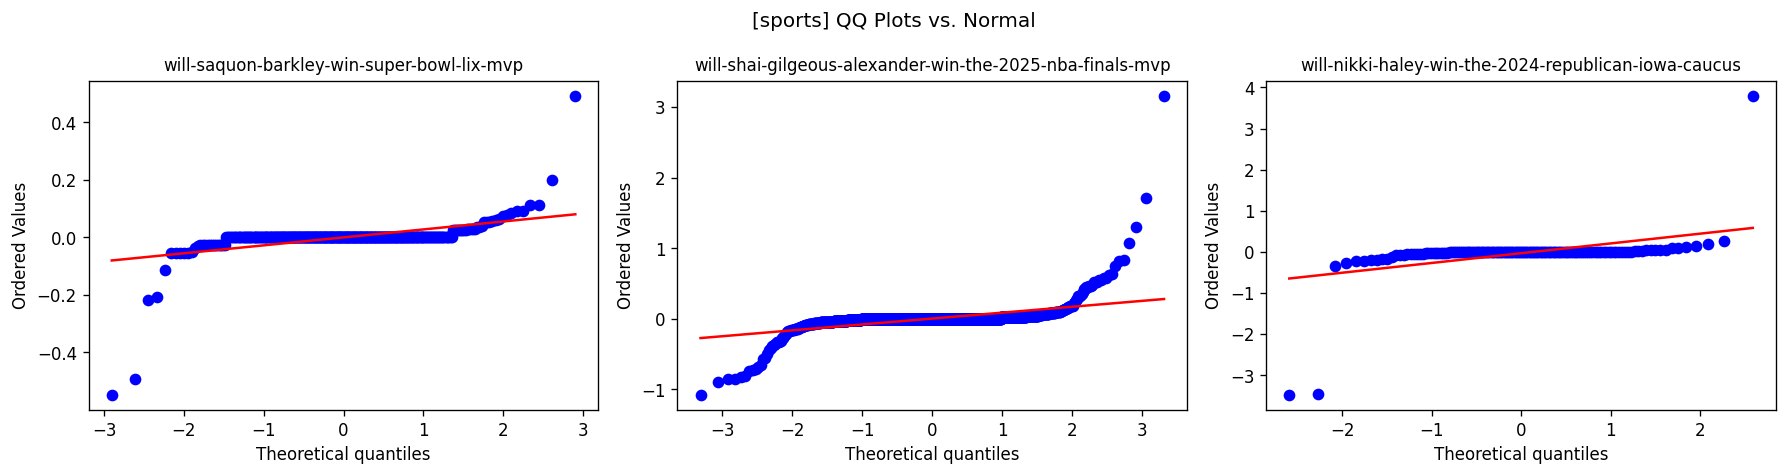

In [15]:
for tid, fds in triad_features.items():
    print(f"\n{'═'*60}")
    print(f"  TRIAD: {tid}")
    print(f"{'═'*60}")
    
    stats_df = cross_triad_stats(fds)
    display(stats_df.round(4))
    
    fig = plot_return_histograms(fds)
    fig.suptitle(f"[{tid}] Logit-Return Distributions", fontsize=12)
    plt.show()
    
    fig = plot_qq(fds)
    fig.suptitle(f"[{tid}] QQ Plots vs. Normal", fontsize=12)
    plt.show()

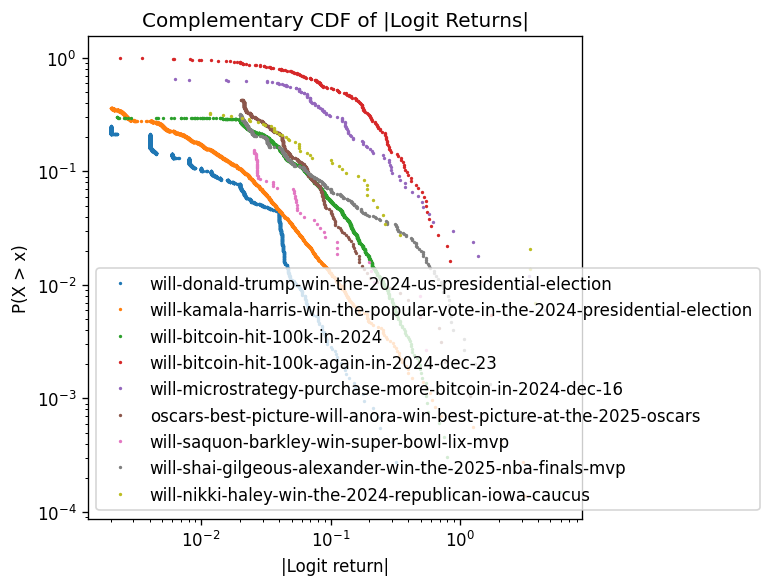

In [16]:
# Tail CCDF: all 9 markets on one plot
fig = plot_tail_ccdf(all_features)
plt.show()

In [17]:
# Power-law tail fits per triad
for tid, fds in triad_features.items():
    print(f"\n--- Triad: {tid} ---")
    try:
        tail_df = cross_triad_tail_table(fds)
        display(tail_df.round(4))
    except Exception as e:
        print(f"  Tail fitting error: {e}")


--- Triad: politics ---


/Users/hetp/Documents/UWaterloo/4B/SYDE 532/Project/venv/lib/python3.13/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution lognormal.
  warnings.warn(f"No valid fits found for distribution {self.name}.")
/Users/hetp/Documents/UWaterloo/4B/SYDE 532/Project/venv/lib/python3.13/site-packages/powerlaw/distributions.py:2884: UserWarning: Likely underflow or overflow error: the optimal fit for this distribution gives values that are so extreme that we lack the numerical precision to calculate them.
  warnings.warn("Likely underflow or overflow error: the optimal fit for this distribution gives values that are so extreme that we lack the numerical precision to calculate them.")


,alpha,xmin,R_vs_lognormal,p_vs_lognormal,R_vs_exponential,p_vs_exponential
market_slug,,,,,,
will-donald-trump-win-the-2024-us-presidential-election,2.9622,0.0479,-0.5619,0.4681,4.6293,0.2100
will-kamala-harris-win-the-popular-vote-in-the-2024-presidential-election,2.4241,0.0456,0.0014,0.9024,116.4478,0.0009
will-bitcoin-hit-100k-in-2024,2.4529,0.0565,-21.8964,0.0033,56.0311,0.3591



--- Triad: crypto ---


/Users/hetp/Documents/UWaterloo/4B/SYDE 532/Project/venv/lib/python3.13/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution lognormal.
  warnings.warn(f"No valid fits found for distribution {self.name}.")
/Users/hetp/Documents/UWaterloo/4B/SYDE 532/Project/venv/lib/python3.13/site-packages/powerlaw/distributions.py:2884: UserWarning: Likely underflow or overflow error: the optimal fit for this distribution gives values that are so extreme that we lack the numerical precision to calculate them.
  warnings.warn("Likely underflow or overflow error: the optimal fit for this distribution gives values that are so extreme that we lack the numerical precision to calculate them.")


,alpha,xmin,R_vs_lognormal,p_vs_lognormal,R_vs_exponential,p_vs_exponential
market_slug,,,,,,
will-bitcoin-hit-100k-again-in-2024-dec-23,2.7104,0.1557,-1.0395,0.3939,4.1371,0.4154
will-microstrategy-purchase-more-bitcoin-in-2024-dec-16,2.2710,0.2954,0.0001,0.9659,4.8735,0.0498
oscars-best-picture-will-anora-win-best-picture-at-the-2025-oscars,2.8317,0.0603,-1.8921,0.0089,30.6982,0.0017



--- Triad: sports ---


,alpha,xmin,R_vs_lognormal,p_vs_lognormal,R_vs_exponential,p_vs_exponential
market_slug,,,,,,
will-saquon-barkley-win-super-bowl-lix-mvp,2.2565,0.0548,-0.0364,0.8509,2.9984,0.2024
will-shai-gilgeous-alexander-win-the-2025-nba-finals-mvp,1.9056,0.0294,-1.4148,0.2327,111.3807,0.0000
will-nikki-haley-win-the-2024-republican-iowa-caucus,1.7755,0.0304,-0.0379,0.8448,34.3197,0.0000


---
# Section 2 – Volatility Clustering

ACF of absolute returns, Ljung-Box tests, rolling volatility, burst detection.


════════════════════════════════════════════════════════════
  TRIAD: politics — ACF of |Logit Returns|
════════════════════════════════════════════════════════════


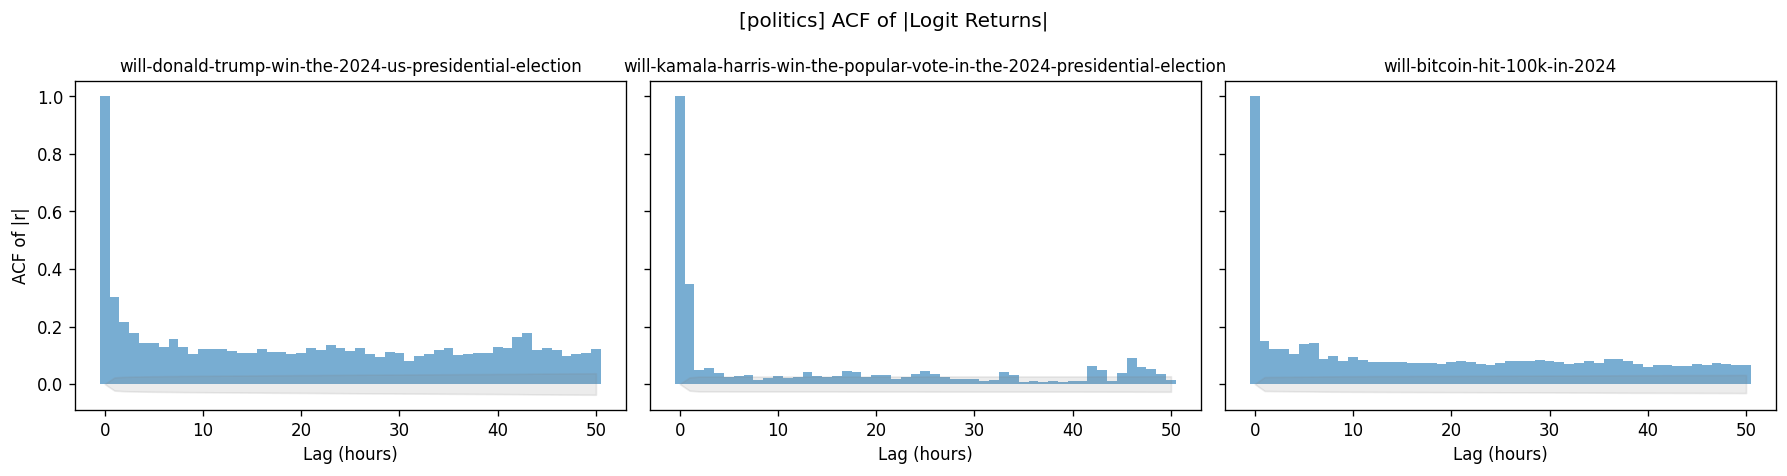

  will-donald-trump-win-the-2024-us-presidentia  LB(10) p=0.0000  LB(20) p=0.0000
  will-kamala-harris-win-the-popular-vote-in-th  LB(10) p=0.0000  LB(20) p=0.0000
  will-bitcoin-hit-100k-in-2024                  LB(10) p=0.0000  LB(20) p=0.0000

════════════════════════════════════════════════════════════
  TRIAD: crypto — ACF of |Logit Returns|
════════════════════════════════════════════════════════════


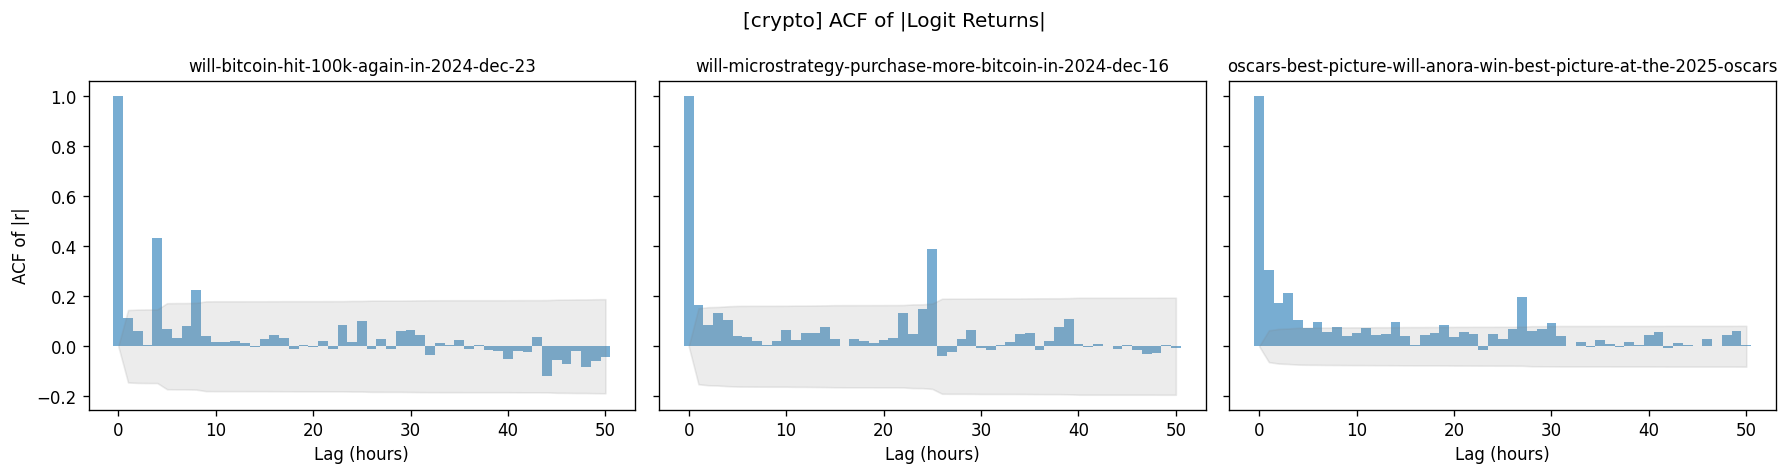

  will-bitcoin-hit-100k-again-in-2024-dec-23     LB(10) p=0.0000  LB(20) p=0.0001
  will-microstrategy-purchase-more-bitcoin-in-2  LB(10) p=0.2741  LB(20) p=0.7798
  oscars-best-picture-will-anora-win-best-pictu  LB(10) p=0.0000  LB(20) p=0.0000

════════════════════════════════════════════════════════════
  TRIAD: sports — ACF of |Logit Returns|
════════════════════════════════════════════════════════════


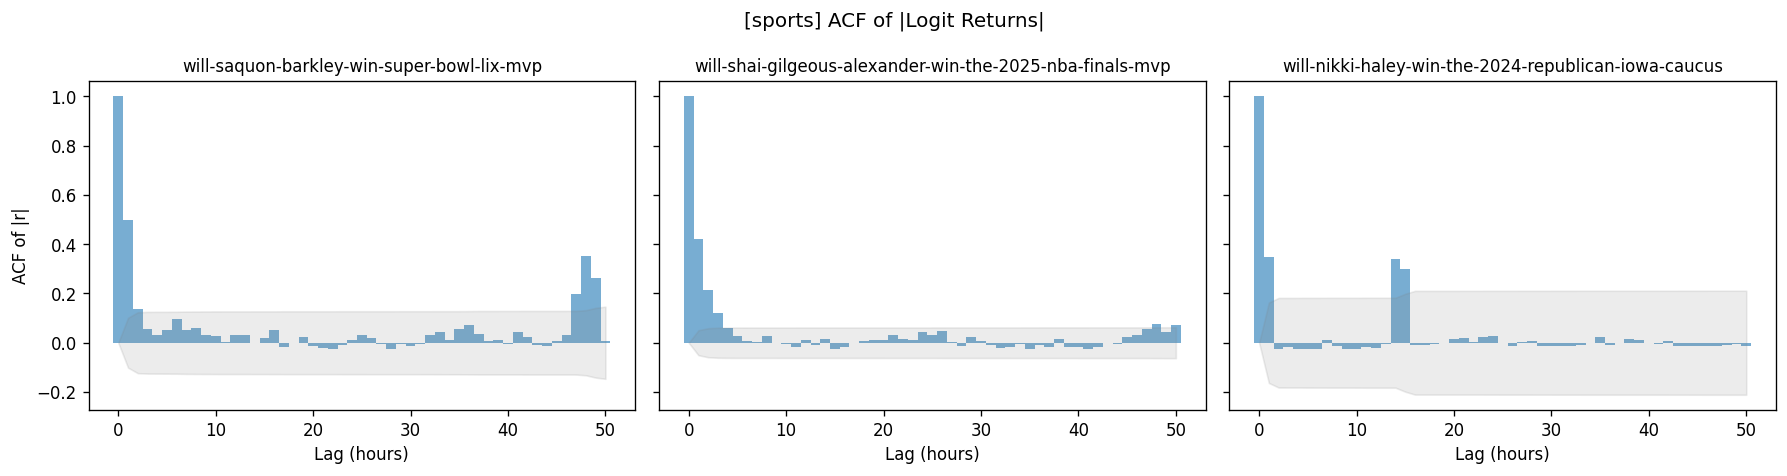

  will-saquon-barkley-win-super-bowl-lix-mvp     LB(10) p=0.0000  LB(20) p=0.0000
  will-shai-gilgeous-alexander-win-the-2025-nba  LB(10) p=0.0000  LB(20) p=0.0000
  will-nikki-haley-win-the-2024-republican-iowa  LB(10) p=0.0506  LB(20) p=0.0001


In [18]:
for tid, fds in triad_features.items():
    print(f"\n{'═'*60}")
    print(f"  TRIAD: {tid} — ACF of |Logit Returns|")
    print(f"{'═'*60}")
    
    fig = plot_acf_panels(fds, nlags=min(50, min(len(df)-2 for df in fds.values())))
    fig.suptitle(f"[{tid}] ACF of |Logit Returns|", fontsize=12)
    plt.show()
    
    # Ljung-Box
    for slug, df in fds.items():
        try:
            lb = ljung_box_test(df, lags=[10, 20])
            print(f"  {slug[:45]:45s}  LB(10) p={lb.iloc[0]['lb_pvalue']:.4f}  LB(20) p={lb.iloc[1]['lb_pvalue']:.4f}")
        except Exception as e:
            print(f"  {slug[:45]:45s}  LB error: {e}")

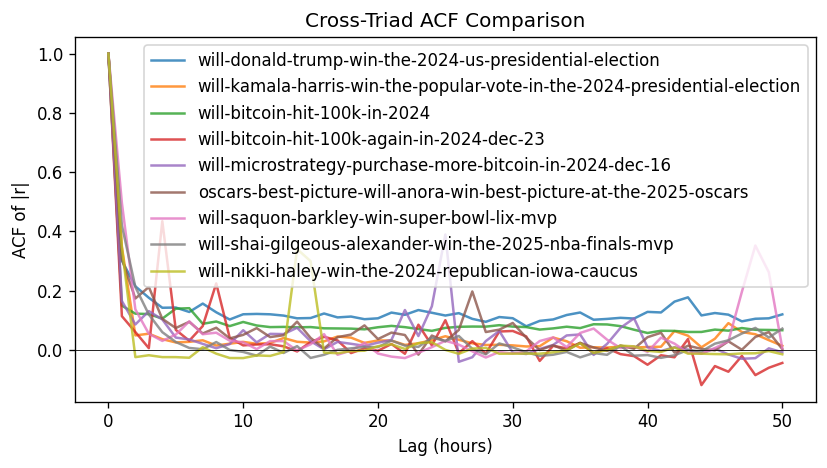

In [19]:
# ACF overlay: all markets
max_lag = min(50, min(len(df)-2 for df in all_features.values()))
fig = plot_acf_overlay(all_features, nlags=max_lag)
plt.show()

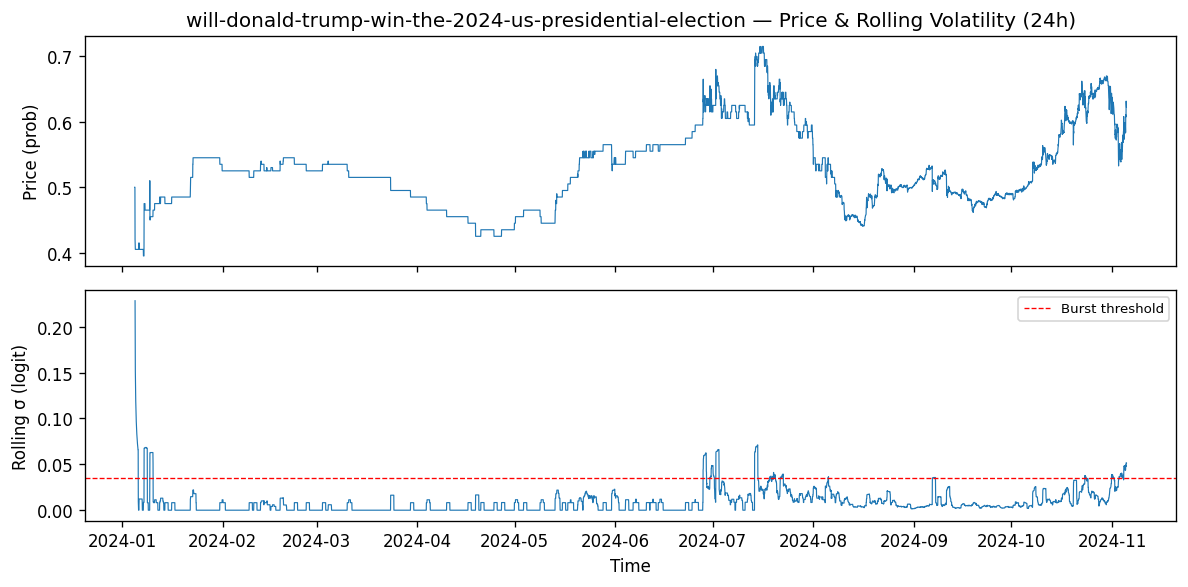

  [politics] will-donald-trump-win-the-2024-us-presid:  21 bursts, mean duration 16.3h


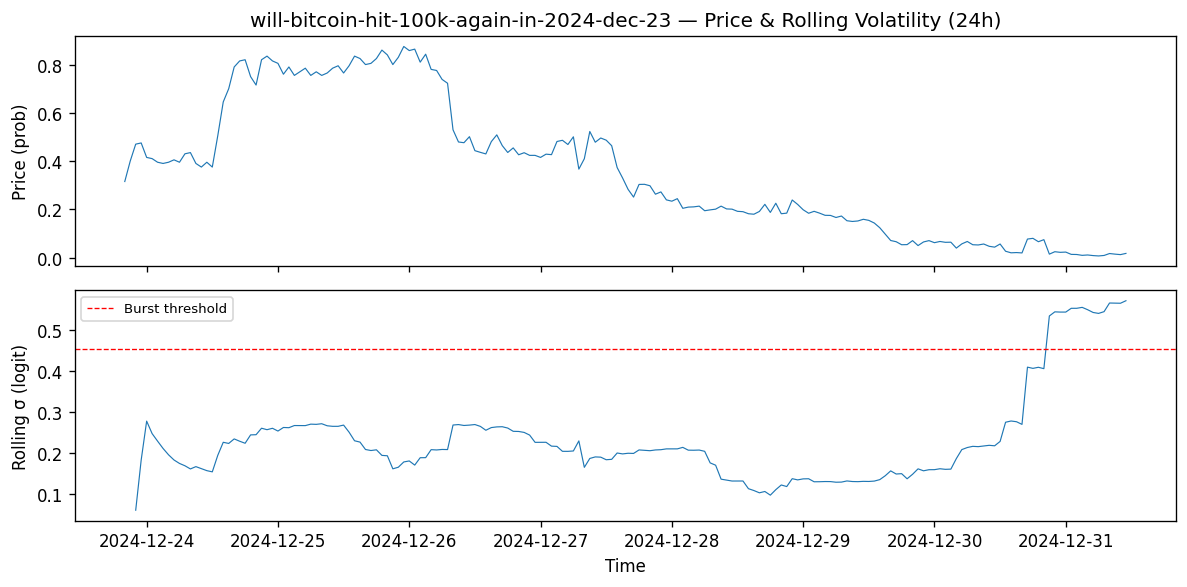

  [crypto] will-bitcoin-hit-100k-again-in-2024-dec-:  1 bursts, mean duration 15.0h


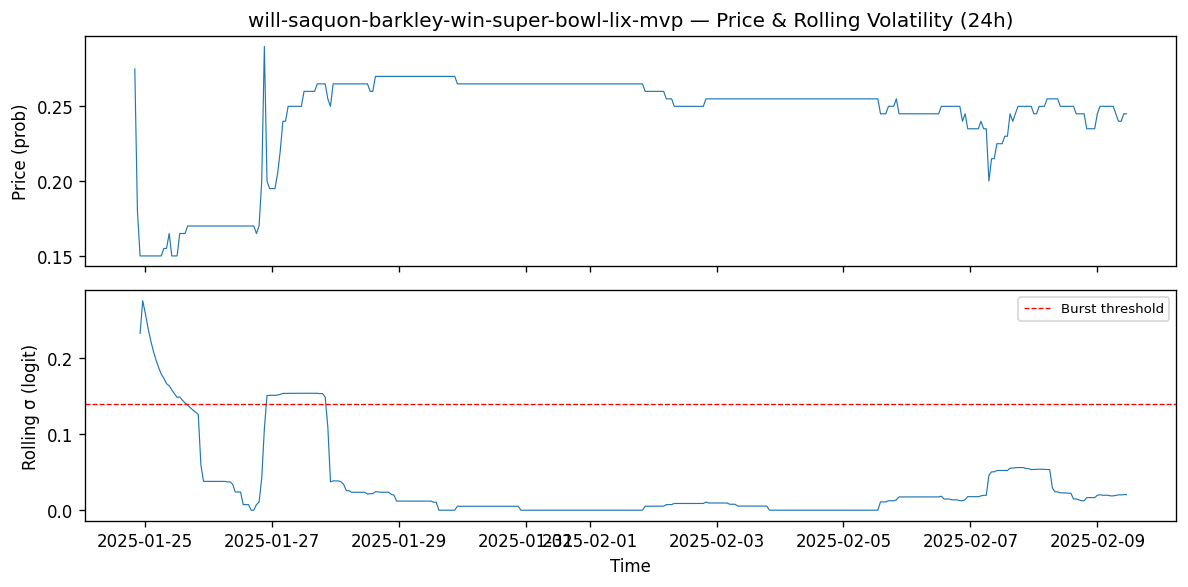

  [sports] will-saquon-barkley-win-super-bowl-lix-m:  2 bursts, mean duration 20.5h


In [20]:
# Rolling volatility + burst detection for base markets
for tid, markets in TRIADS.items():
    base_slug = markets[0]['slug']
    if base_slug in all_features:
        fig = plot_rolling_vol_with_price(all_features[base_slug], base_slug, window=24)
        plt.show()
        
        bursts = detect_bursts(all_features[base_slug], window=24)
        bs = burst_summary(bursts)
        print(f"  [{tid}] {base_slug[:40]}:  {bs['n_bursts']} bursts, mean duration {bs['mean_duration_h']:.1f}h")

---
# Section 3 – Reversal / Overshoot

Conditional returns after large positive and negative moves.


════════════════════════════════════════════════════════════
  TRIAD: politics — Reversal Analysis
════════════════════════════════════════════════════════════


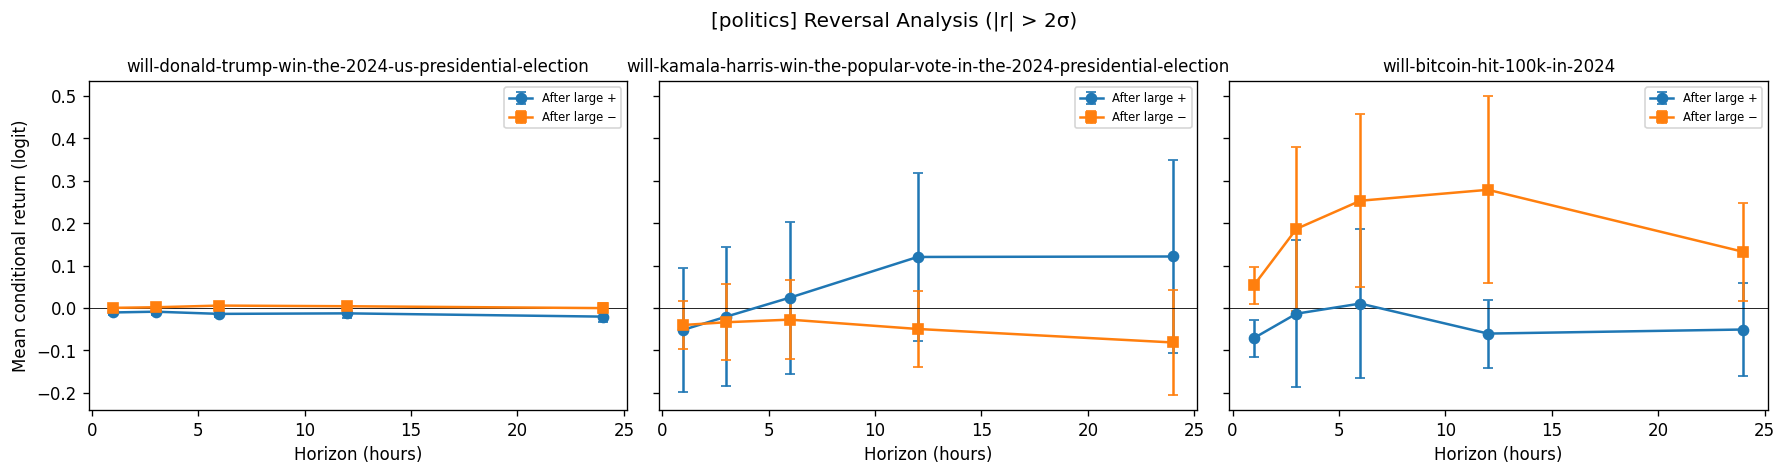


  will-donald-trump-win-the-2024-us-presidential-ele:


,mean_after_pos,se_after_pos,n_pos,tstat_pos,pval_pos,mean_after_neg,se_after_neg,n_neg,tstat_neg,pval_neg
horizon,,,,,,,,,,
1,-0.0103,0.0028,182,-3.7483,0.0002,0.0005,0.0023,179,0.2193,0.8266
3,-0.0085,0.0037,181,-2.3346,0.0207,0.0019,0.0032,179,0.5938,0.5534
6,-0.0137,0.0035,180,-3.9050,0.0001,0.0059,0.0043,179,1.3620,0.1749
12,-0.0125,0.0051,180,-2.4644,0.0147,0.0043,0.0046,178,0.9309,0.3532
24,-0.0201,0.0061,177,-3.3057,0.0011,-0.0001,0.0058,176,-0.0184,0.9853



  will-kamala-harris-win-the-popular-vote-in-the-202:


,mean_after_pos,se_after_pos,n_pos,tstat_pos,pval_pos,mean_after_neg,se_after_neg,n_neg,tstat_neg,pval_neg
horizon,,,,,,,,,,
1,-0.0512,0.0744,31,-0.6875,0.4971,-0.0399,0.0292,27,-1.3685,0.1829
3,-0.0203,0.0835,31,-0.2436,0.8092,-0.0334,0.0457,27,-0.7313,0.4711
6,0.0246,0.0915,31,0.2687,0.7900,-0.0273,0.0471,27,-0.5790,0.5676
12,0.1205,0.1008,31,1.1945,0.2416,-0.0493,0.0455,27,-1.0824,0.2890
24,0.1216,0.1158,31,1.0502,0.3020,-0.0811,0.0629,26,-1.2901,0.2088



  will-bitcoin-hit-100k-in-2024:


,mean_after_pos,se_after_pos,n_pos,tstat_pos,pval_pos,mean_after_neg,se_after_neg,n_neg,tstat_neg,pval_neg
horizon,,,,,,,,,,
1,-0.0708,0.0222,69,-3.1879,0.0022,0.0536,0.0221,61,2.4276,0.0182
3,-0.0132,0.0887,68,-0.1492,0.8818,0.1867,0.0987,61,1.8927,0.0632
6,0.0106,0.0900,67,0.1180,0.9064,0.2530,0.1038,60,2.4368,0.0179
12,-0.0601,0.0409,66,-1.4694,0.1466,0.2788,0.1123,59,2.4828,0.0160
24,-0.0505,0.0556,66,-0.9091,0.3666,0.1325,0.0591,58,2.2431,0.0288



════════════════════════════════════════════════════════════
  TRIAD: crypto — Reversal Analysis
════════════════════════════════════════════════════════════


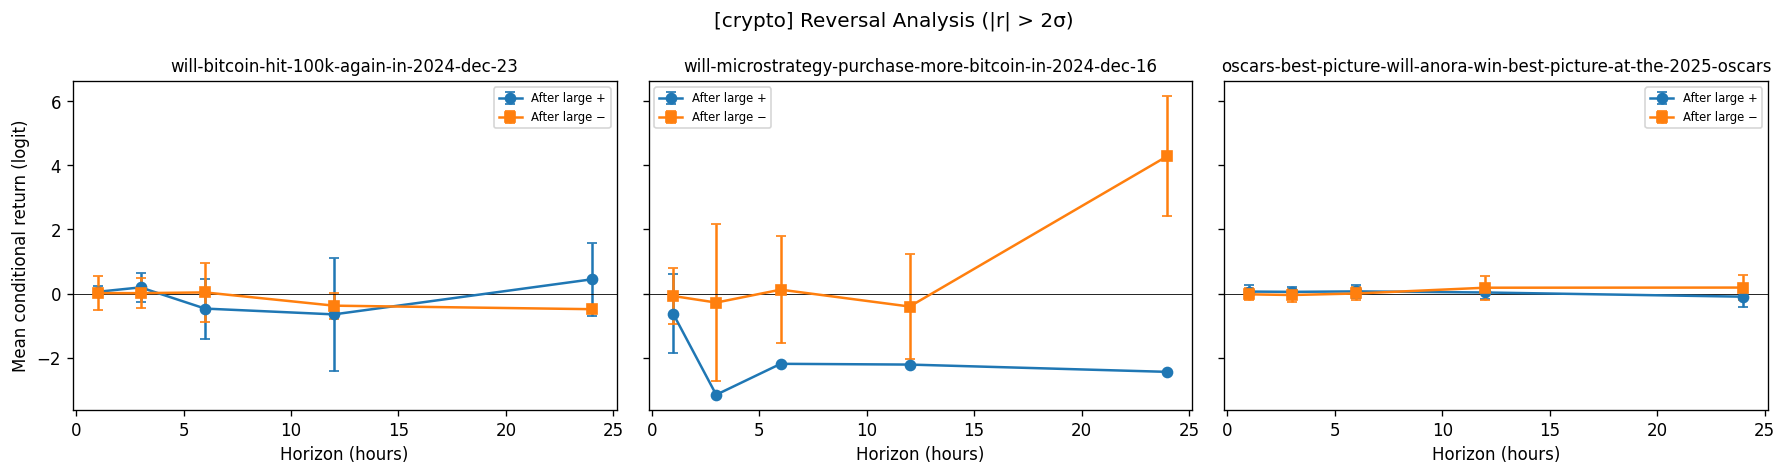


  will-bitcoin-hit-100k-again-in-2024-dec-23:


,mean_after_pos,se_after_pos,n_pos,tstat_pos,pval_pos,mean_after_neg,se_after_neg,n_neg,tstat_neg,pval_neg
horizon,,,,,,,,,,
1,0.0575,0.0866,4,0.6646,0.5538,0.0176,0.2671,3,0.0657,0.9536
3,0.1954,0.2316,4,0.8437,0.4608,0.0161,0.2410,3,0.0666,0.9530
6,-0.4651,0.4777,3,-0.9737,0.4329,0.0388,0.4635,3,0.0837,0.9409
12,-0.6459,0.8960,3,-0.7208,0.5459,-0.3742,0.2050,3,-1.8255,0.2095
24,0.4472,0.5772,2,0.7747,0.5804,-0.4842,NaN,1,NaN,NaN



  will-microstrategy-purchase-more-bitcoin-in-2024-d:


,mean_after_pos,se_after_pos,n_pos,tstat_pos,pval_pos,mean_after_neg,se_after_neg,n_neg,tstat_neg,pval_neg
horizon,,,,,,,,,,
1,-0.6273,0.6273,2,-1.0,0.5,-0.0730,0.4492,2,-0.1626,0.8974
3,-3.1509,NaN,1,NaN,NaN,-0.2779,1.2422,2,-0.2237,0.8599
6,-2.1866,NaN,1,NaN,NaN,0.1245,0.8559,2,0.1454,0.9080
12,-2.2103,NaN,1,NaN,NaN,-0.4015,0.8383,2,-0.4790,0.7156
24,-2.4376,NaN,1,NaN,NaN,4.2892,0.9481,2,4.5239,0.1385



  oscars-best-picture-will-anora-win-best-picture-at:


,mean_after_pos,se_after_pos,n_pos,tstat_pos,pval_pos,mean_after_neg,se_after_neg,n_neg,tstat_neg,pval_neg
horizon,,,,,,,,,,
1,0.0651,0.1050,12,0.6203,0.5477,-0.0211,0.0950,10,-0.2223,0.8290
3,0.0561,0.0699,12,0.8031,0.4389,-0.0423,0.1033,10,-0.4093,0.6919
6,0.0704,0.1020,12,0.6901,0.5044,0.0051,0.1112,10,0.0458,0.9645
12,0.0366,0.1033,12,0.3546,0.7296,0.1854,0.1940,10,0.9556,0.3642
24,-0.0944,0.1630,11,-0.5795,0.5751,0.1897,0.2045,10,0.9276,0.3778



════════════════════════════════════════════════════════════
  TRIAD: sports — Reversal Analysis
════════════════════════════════════════════════════════════


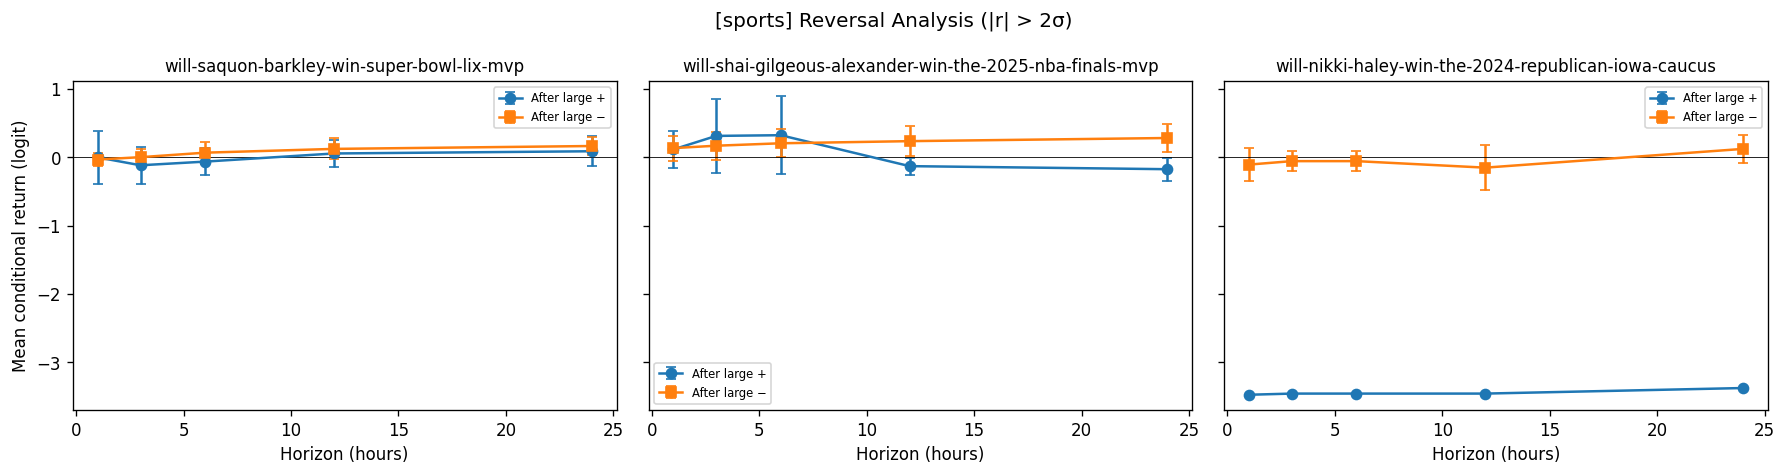


  will-saquon-barkley-win-super-bowl-lix-mvp:


,mean_after_pos,se_after_pos,n_pos,tstat_pos,pval_pos,mean_after_neg,se_after_neg,n_neg,tstat_neg,pval_neg
horizon,,,,,,,,,,
1,0.0000,0.2004,4,0.0000,1.0000,-0.0317,0.0510,5,-0.6223,0.5674
3,-0.1160,0.1367,4,-0.8486,0.4585,0.0026,0.0647,5,0.0397,0.9702
6,-0.0623,0.1028,4,-0.6067,0.5869,0.0685,0.0814,5,0.8407,0.4478
12,0.0568,0.1016,4,0.5587,0.6154,0.1238,0.0781,5,1.5850,0.1881
24,0.0895,0.1126,4,0.7944,0.4850,0.1661,0.0681,5,2.4398,0.0712



  will-shai-gilgeous-alexander-win-the-2025-nba-fina:


,mean_after_pos,se_after_pos,n_pos,tstat_pos,pval_pos,mean_after_neg,se_after_neg,n_neg,tstat_neg,pval_neg
horizon,,,,,,,,,,
1,0.1152,0.1397,28,0.8243,0.4170,0.1352,0.0926,23,1.4589,0.1587
3,0.3142,0.2780,28,1.1303,0.2683,0.1705,0.1046,23,1.6296,0.1174
6,0.3244,0.2898,27,1.1196,0.2731,0.2060,0.1033,23,1.9954,0.0585
12,-0.1286,0.0642,24,-2.0027,0.0571,0.2374,0.1114,23,2.1315,0.0445
24,-0.1735,0.0854,24,-2.0309,0.0540,0.2834,0.1022,23,2.7722,0.0111



  will-nikki-haley-win-the-2024-republican-iowa-cauc:


,mean_after_pos,se_after_pos,n_pos,tstat_pos,pval_pos,mean_after_neg,se_after_neg,n_neg,tstat_neg,pval_neg
horizon,,,,,,,,,,
1,-3.4761,NaN,1,NaN,NaN,-0.1061,0.1232,2,-0.8616,0.5472
3,-3.4591,NaN,1,NaN,NaN,-0.0553,0.0723,2,-0.7644,0.5845
6,-3.4591,NaN,1,NaN,NaN,-0.0553,0.0723,2,-0.7644,0.5845
12,-3.4591,NaN,1,NaN,NaN,-0.1507,0.1677,2,-0.8984,0.5341
24,-3.3777,NaN,1,NaN,NaN,0.1240,0.1069,2,1.1594,0.4531


In [21]:
for tid, fds in triad_features.items():
    print(f"\n{'═'*60}")
    print(f"  TRIAD: {tid} — Reversal Analysis")
    print(f"{'═'*60}")
    
    fig = plot_conditional_returns(fds)
    fig.suptitle(f"[{tid}] Reversal Analysis (|r| > 2σ)", fontsize=12)
    plt.show()
    
    tables = cross_triad_reversal_table(fds)
    for slug, cr in tables.items():
        print(f"\n  {slug[:50]}:")
        display(cr.round(4))

---
# Section 4 – Liquidity & Activity Regressions

Bin stratification by trade rate, deadline effects, OLS regressions.


════════════════════════════════════════════════════════════
  TRIAD: politics — Trade-Rate Stratification
════════════════════════════════════════════════════════════


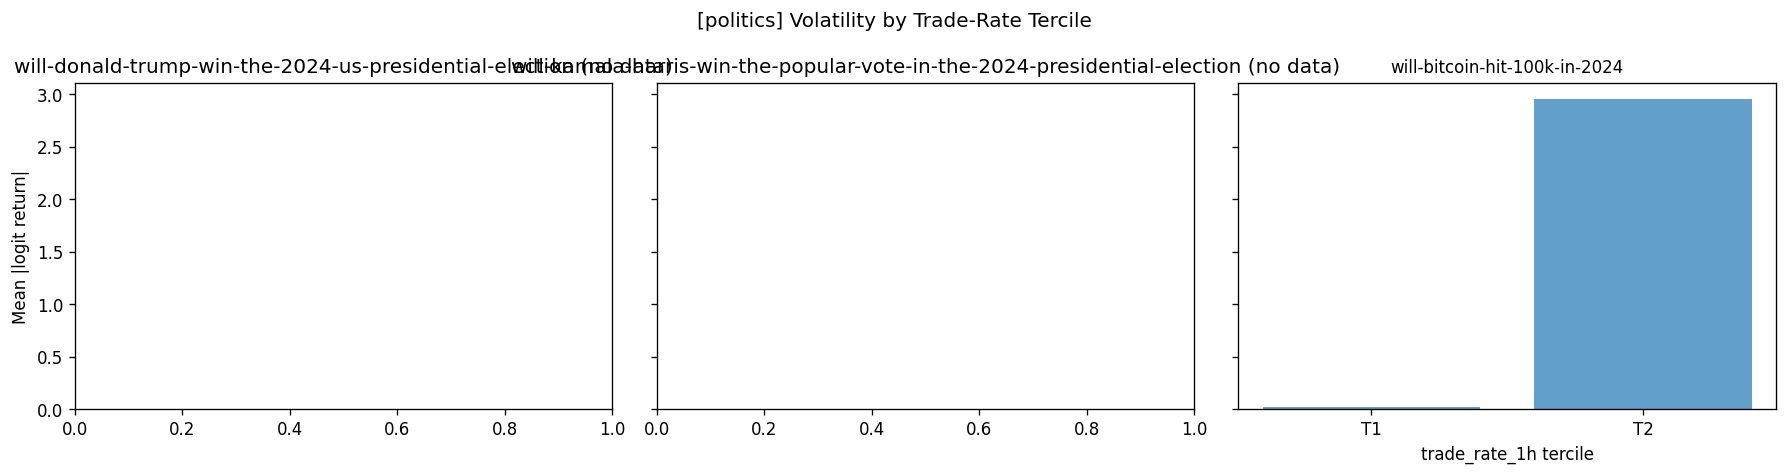


════════════════════════════════════════════════════════════
  TRIAD: crypto — Trade-Rate Stratification
════════════════════════════════════════════════════════════


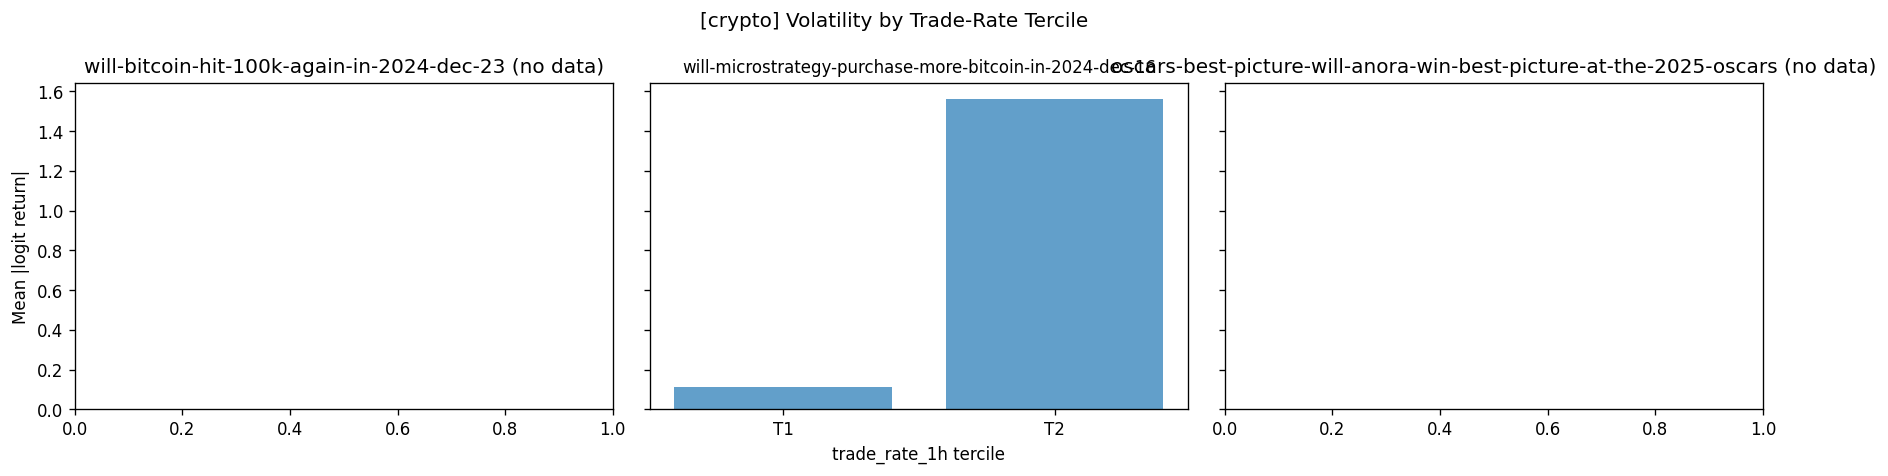


════════════════════════════════════════════════════════════
  TRIAD: sports — Trade-Rate Stratification
════════════════════════════════════════════════════════════


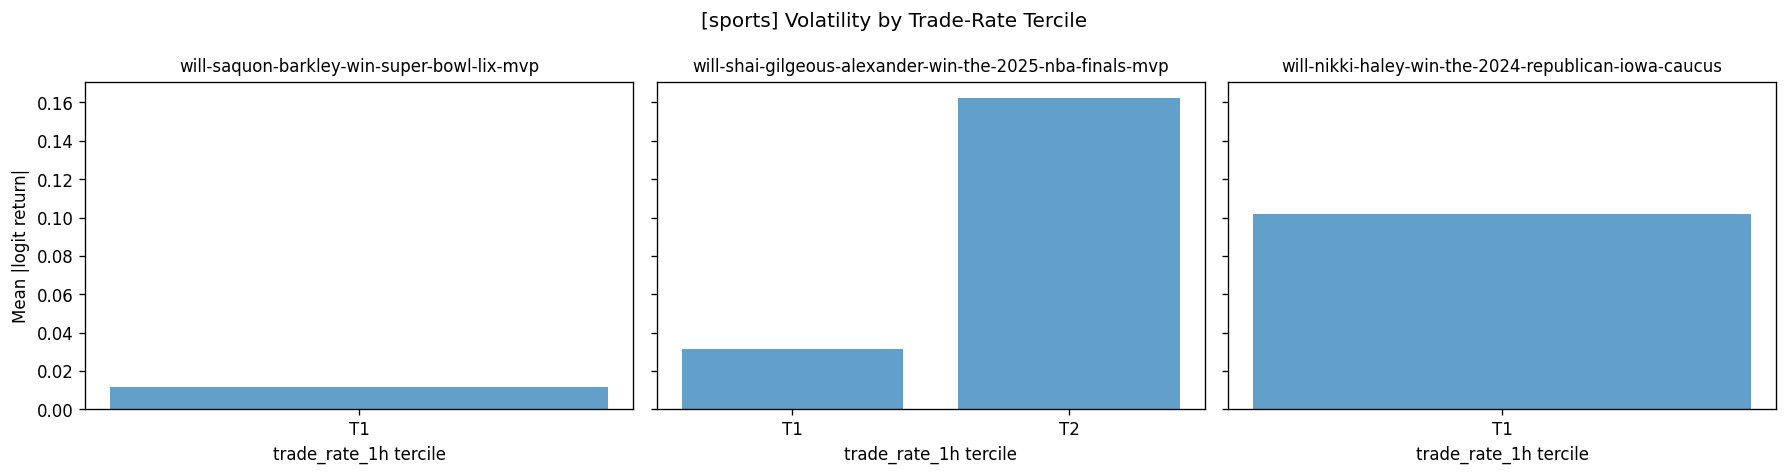

In [22]:
for tid, fds in triad_features.items():
    print(f"\n{'═'*60}")
    print(f"  TRIAD: {tid} — Trade-Rate Stratification")
    print(f"{'═'*60}")
    
    fig = plot_bin_stratification(fds, bin_col="trade_rate_1h", n_bins=3)
    fig.suptitle(f"[{tid}] Volatility by Trade-Rate Tercile", fontsize=12)
    plt.show()

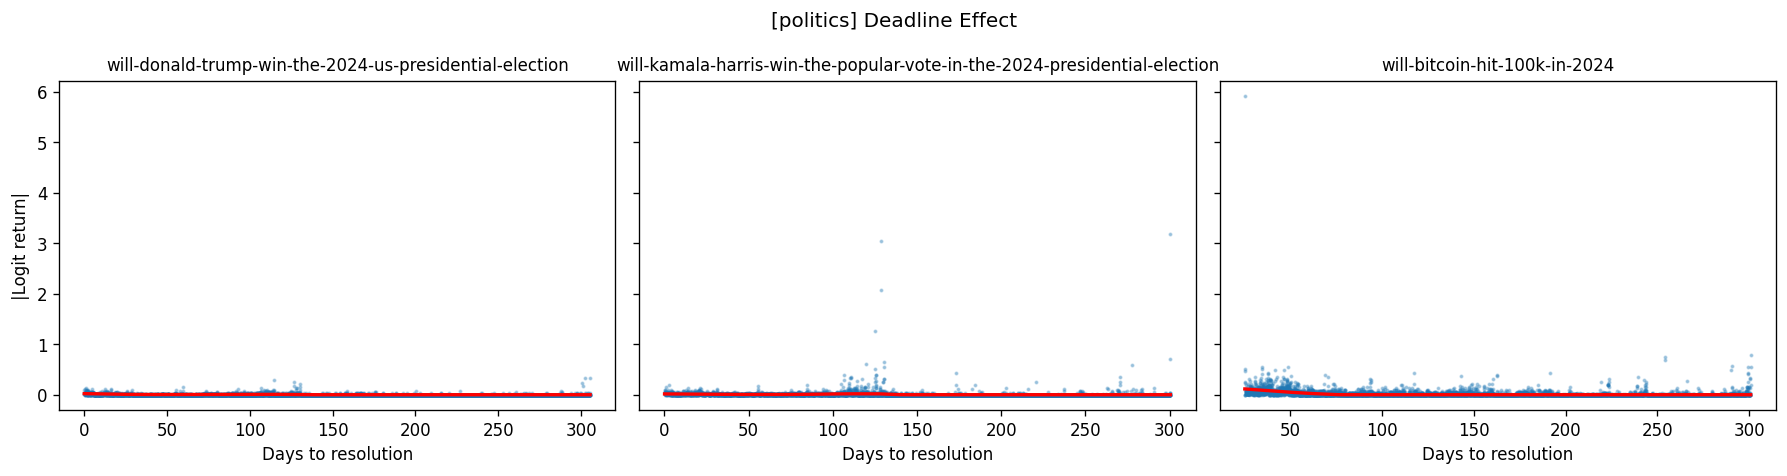

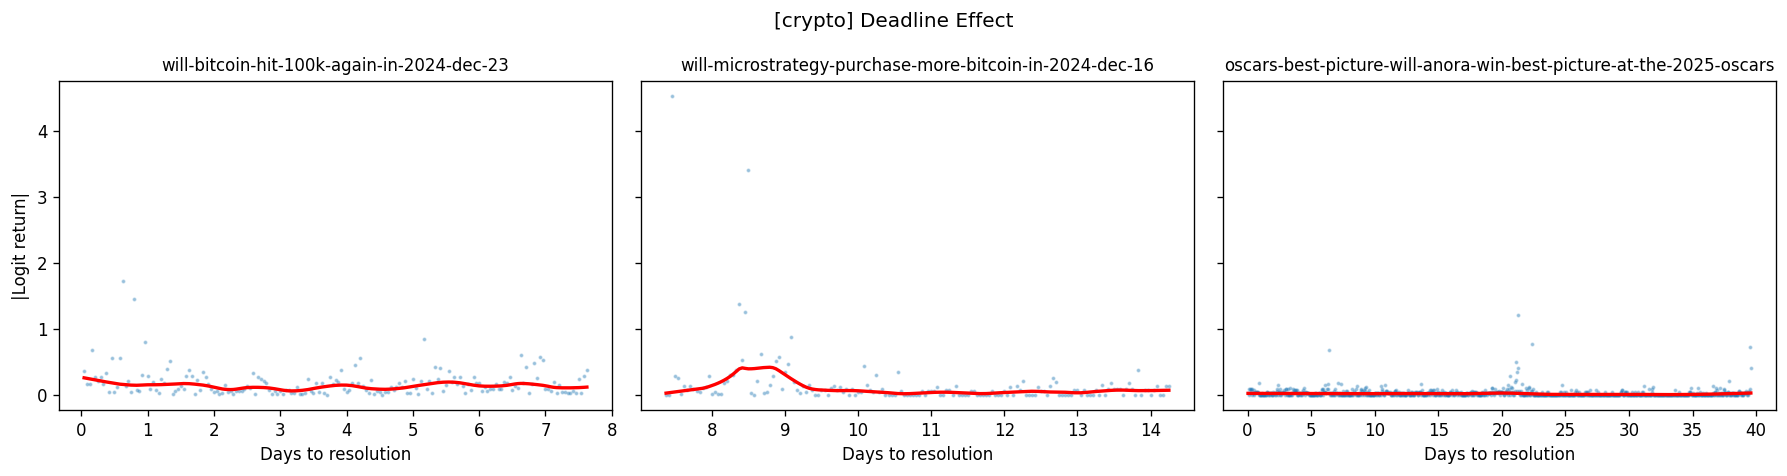

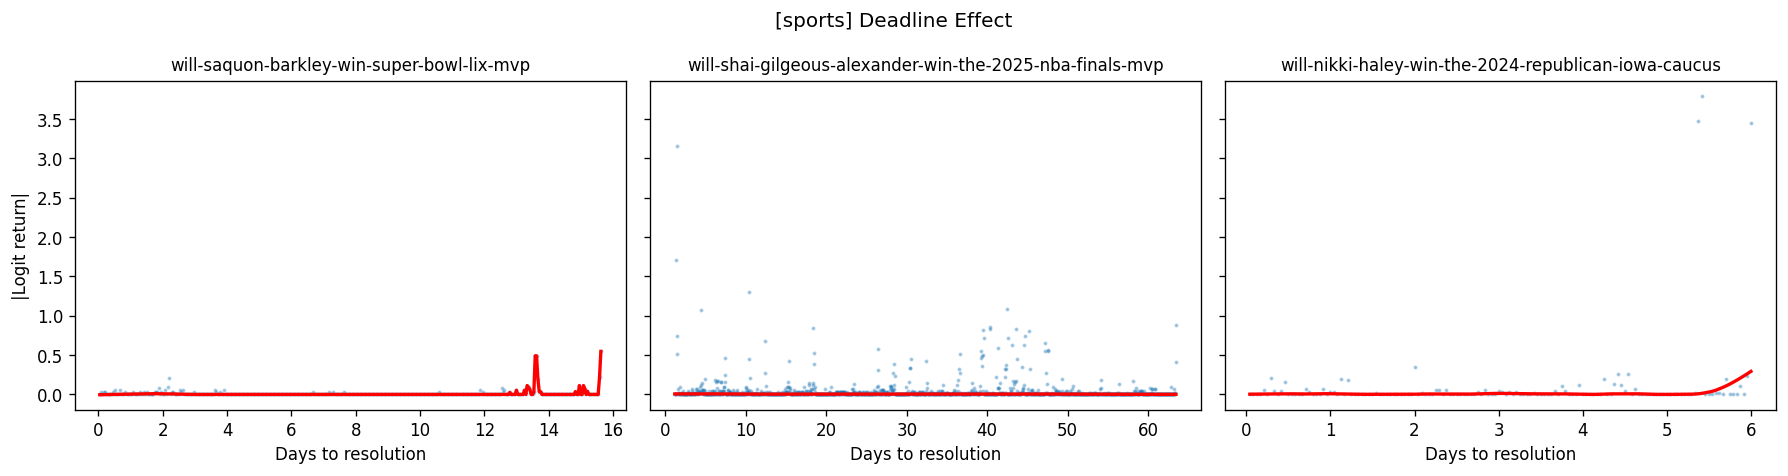

In [23]:
# Deadline effect per triad
for tid, fds in triad_features.items():
    fig = plot_deadline_effect(fds)
    fig.suptitle(f"[{tid}] Deadline Effect", fontsize=12)
    plt.show()

In [24]:
# OLS: |r_t| ~ trade_rate_1h + time_to_resolution (pooled across all markets)
features_all = pd.read_parquet(DATA_PROCESSED / "features_all.parquet")
try:
    model = ols_volatility_activity(features_all)
    print(model.summary())
except Exception as e:
    print(f"OLS error: {e}")

                            OLS Regression Results                            
Dep. Variable:       abs_logit_return   R-squared:                       0.028
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     75.33
Date:                Sat, 28 Feb 2026   Prob (F-statistic):           1.38e-63
Time:                        14:38:26   Log-Likelihood:                 23431.
No. Observations:               24469   AIC:                        -4.685e+04
Df Residuals:                   24464   BIC:                        -4.681e+04
Df Model:                           4                                         
Covariance Type:                  HC1                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.0329      0

---
# Section 5 – Cross-Triad Consistency & Stage 2 Decision

Aggregate diagnostics across all 3 triads and test whether findings are
consistent enough to proceed to Stage 2 (pooled modelling).

In [25]:
# Within-triad summaries
triad_summaries: dict[str, pd.DataFrame] = {}
for tid, fds in triad_features.items():
    triad_summaries[tid] = within_triad_summary(fds)
    print(f"\n--- Triad: {tid} ---")
    display(triad_summaries[tid].round(4))


--- Triad: politics ---


/Users/hetp/Documents/UWaterloo/4B/SYDE 532/Project/venv/lib/python3.13/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution lognormal.
  warnings.warn(f"No valid fits found for distribution {self.name}.")
/Users/hetp/Documents/UWaterloo/4B/SYDE 532/Project/venv/lib/python3.13/site-packages/powerlaw/distributions.py:2884: UserWarning: Likely underflow or overflow error: the optimal fit for this distribution gives values that are so extreme that we lack the numerical precision to calculate them.
  warnings.warn("Likely underflow or overflow error: the optimal fit for this distribution gives values that are so extreme that we lack the numerical precision to calculate them.")


,triad_id,role,n_obs,mean_return,std_return,skewness,excess_kurtosis,jarque_bera_p,ljung_box_10_p,ljung_box_20_p,n_bursts,mean_burst_duration_h,tail_alpha,tail_xmin,reversal_after_pos_h6,reversal_after_neg_h6
market_slug,,,,,,,,,,,,,,,,
will-donald-trump-win-the-2024-us-presidential-election,politics,base,7332,0.0001,0.0151,1.1413,121.3462,0.0,0.0,0.0,21,16.2857,2.9622,0.0479,-0.0137,0.0059
will-kamala-harris-win-the-popular-vote-in-the-2024-presidential-election,politics,similar,7211,0.0001,0.0668,-5.0025,1459.5518,0.0,0.0,0.0,4,23.0000,2.4241,0.0456,0.0246,-0.0273
will-bitcoin-hit-100k-in-2024,politics,dissimilar,6612,0.0012,0.0923,40.0928,2570.1424,0.0,0.0,0.0,13,18.1538,2.4529,0.0565,0.0106,0.2530



--- Triad: crypto ---


/Users/hetp/Documents/UWaterloo/4B/SYDE 532/Project/venv/lib/python3.13/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution lognormal.
  warnings.warn(f"No valid fits found for distribution {self.name}.")
/Users/hetp/Documents/UWaterloo/4B/SYDE 532/Project/venv/lib/python3.13/site-packages/powerlaw/distributions.py:2884: UserWarning: Likely underflow or overflow error: the optimal fit for this distribution gives values that are so extreme that we lack the numerical precision to calculate them.
  warnings.warn("Likely underflow or overflow error: the optimal fit for this distribution gives values that are so extreme that we lack the numerical precision to calculate them.")


,triad_id,role,n_obs,mean_return,std_return,skewness,excess_kurtosis,jarque_bera_p,ljung_box_10_p,ljung_box_20_p,n_bursts,mean_burst_duration_h,tail_alpha,tail_xmin,reversal_after_pos_h6,reversal_after_neg_h6
market_slug,,,,,,,,,,,,,,,,
will-bitcoin-hit-100k-again-in-2024-dec-23,crypto,base,183,-0.0179,0.2795,-0.4787,10.9898,0.0,0.0000,0.0001,1,15.0000,2.7104,0.1557,-0.4651,0.0388
will-microstrategy-purchase-more-bitcoin-in-2024-dec-16,crypto,similar,166,0.0277,0.4913,6.3467,54.1911,0.0,0.2741,0.7798,2,13.0000,2.2710,0.2954,-2.1866,0.1245
oscars-best-picture-will-anora-win-best-picture-at-the-2025-oscars,crypto,dissimilar,950,0.0007,0.0740,4.1140,104.6047,0.0,0.0000,0.0000,3,16.6667,2.8317,0.0603,0.0704,0.0051



--- Triad: sports ---


,triad_id,role,n_obs,mean_return,std_return,skewness,excess_kurtosis,jarque_bera_p,ljung_box_10_p,ljung_box_20_p,n_bursts,mean_burst_duration_h,tail_alpha,tail_xmin,reversal_after_pos_h6,reversal_after_neg_h6
market_slug,,,,,,,,,,,,,,,,
will-saquon-barkley-win-super-bowl-lix-mvp,sports,base,375,-0.0004,0.0529,-3.0586,69.6449,0.0,0.0000,0.0000,2,20.5,2.2565,0.0548,-0.0623,0.0685
will-shai-gilgeous-alexander-win-the-2025-nba-finals-mvp,sports,similar,1496,0.0042,0.1507,7.1519,152.1896,0.0,0.0000,0.0000,5,16.8,1.9056,0.0294,0.3244,0.2060
will-nikki-haley-win-the-2024-republican-iowa-caucus,sports,dissimilar,144,-0.0325,0.5217,-1.2324,43.8348,0.0,0.0506,0.0001,2,3.5,1.7755,0.0304,-3.4591,-0.0553


In [26]:
# Cross-triad consistency
consistency = cross_triad_consistency(triad_summaries)
print("Cross-Triad Consistency Report (low CV = consistent):")
display(consistency.round(4))

Cross-Triad Consistency Report (low CV = consistent):


,overall_mean,overall_std,cv,triad_politics,triad_crypto,triad_sports
metric,,,,,,
n_obs,2718.7778,3754.2889,1.3809,7051.6667,433.0000,671.6667
mean_return,-0.0019,0.0068,3.6635,0.0005,0.0035,-0.0096
std_return,0.1938,0.1192,0.6153,0.0581,0.2816,0.2418
skewness,5.4527,5.8585,1.0744,12.0772,3.3273,0.9536
excess_kurtosis,509.6106,757.1351,1.4857,1383.6801,56.5952,88.5564
jarque_bera_p,0.0000,0.0000,NaN,0.0000,0.0000,0.0000
ljung_box_10_p,0.0361,0.0486,1.3479,0.0000,0.0914,0.0169
ljung_box_20_p,0.0867,0.1501,1.7317,0.0000,0.2600,0.0000
n_bursts,5.8889,5.8910,1.0004,12.6667,2.0000,3.0000


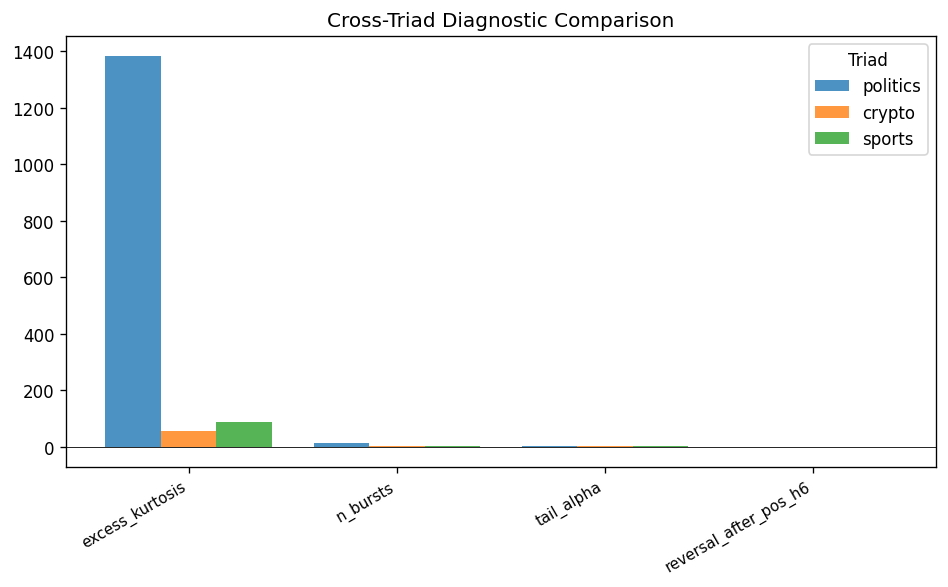

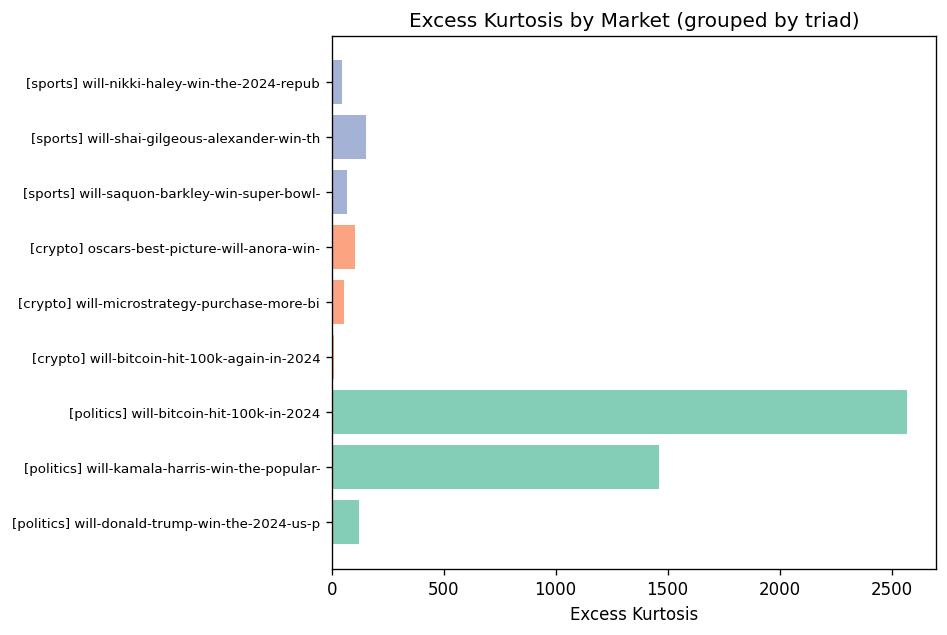

In [27]:
# Signature comparison plots
fig = plot_signature_comparison(triad_summaries)
plt.show()

fig = plot_kurtosis_comparison(triad_summaries)
plt.show()